In [15]:
import subprocess
subprocess.run(["pip", "install", "xgboost", "lightgbm", "shap", "imbalanced-learn", "-q"])

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('/content/Credit_risk_eda.csv')
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: 307,511 rows × 23 cols


In [16]:
# ── Cell 2: Feature Selection & Encoding ─────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Drop non-feature columns
DROP_COLS = ['SK_ID_CURR', 'TARGET', 'AGE_GROUP', 'INCOME_BRACKET']
FEATURE_DF = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# Encode remaining categoricals
le = LabelEncoder()
cat_cols = FEATURE_DF.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    FEATURE_DF[col] = le.fit_transform(FEATURE_DF[col].astype(str))

# Fill any remaining nulls
FEATURE_DF = FEATURE_DF.fillna(0)

X = FEATURE_DF
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Features: {X_train.shape[1]}")
print(f"Default rate in train: {y_train.mean()*100:.2f}%")

Train: 246,008 | Test: 61,503
Features: 19
Default rate in train: 8.07%


In [17]:
# ── Cell 3: SMOTE Oversampling ────────────────────────────────────────
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42, k_neighbors=5)
X_res, y_res = sm.fit_resample(X_train, y_train)

print(f"Before SMOTE — Default: {y_train.sum():,} | Non-default: {(y_train==0).sum():,}")
print(f"After  SMOTE — Default: {y_res.sum():,} | Non-default: {(y_res==0).sum():,}")

Before SMOTE — Default: 19,860 | Non-default: 226,148
After  SMOTE — Default: 226,148 | Non-default: 226,148


In [18]:
# ── Cell 4: XGBoost ───────────────────────────────────────────────────
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_res, y_res,
        eval_set=[(X_test, y_test)],
        verbose=50)

print("✅ XGBoost trained")

[0]	validation_0-auc:0.59492
[50]	validation_0-auc:0.62446
[100]	validation_0-auc:0.62671
[150]	validation_0-auc:0.62866
[200]	validation_0-auc:0.62964
[250]	validation_0-auc:0.63091
[299]	validation_0-auc:0.63222
✅ XGBoost trained


In [19]:
# ── Cell 5: LightGBM ──────────────────────────────────────────────────
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(X_res, y_res,
         eval_set=[(X_test, y_test)],
         callbacks=[])

print("✅ LightGBM trained")

✅ LightGBM trained



XGBoost  |  ROC-AUC: 0.6322
              precision    recall  f1-score   support

  No Default       0.93      0.92      0.92     56538
     Default       0.16      0.17      0.17      4965

    accuracy                           0.86     61503
   macro avg       0.55      0.55      0.55     61503
weighted avg       0.87      0.86      0.86     61503


LightGBM  |  ROC-AUC: 0.6308
              precision    recall  f1-score   support

  No Default       0.93      0.93      0.93     56538
     Default       0.16      0.15      0.15      4965

    accuracy                           0.87     61503
   macro avg       0.54      0.54      0.54     61503
weighted avg       0.86      0.87      0.87     61503



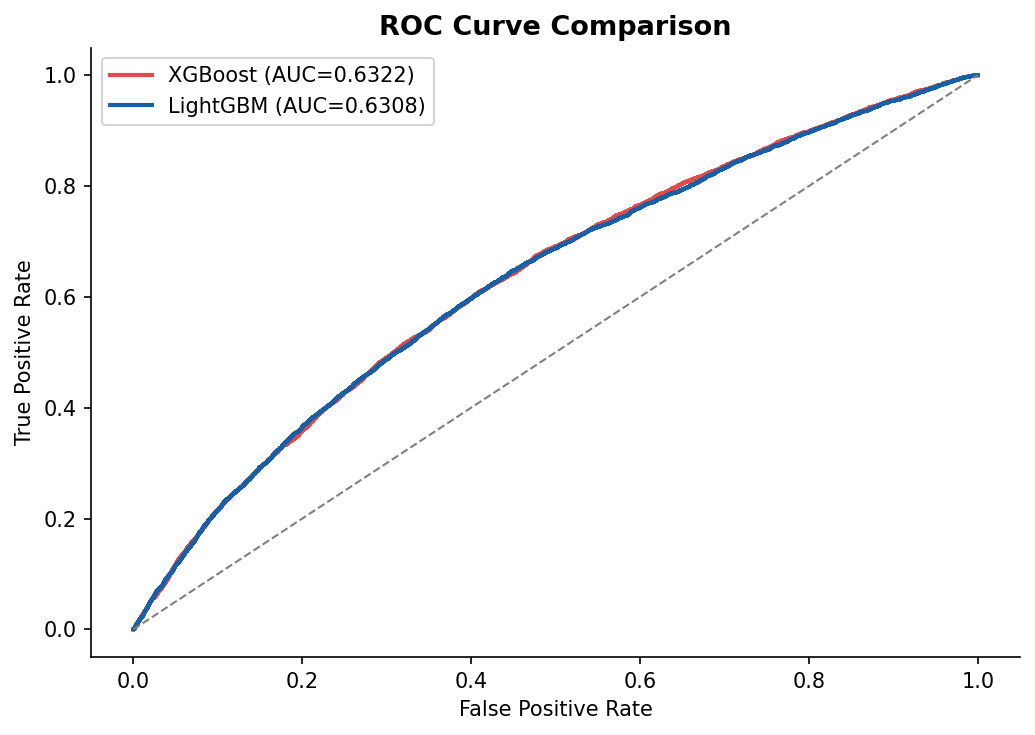

In [20]:
# ── Cell 6: Model Evaluation ──────────────────────────────────────────
from sklearn.metrics import (roc_auc_score, classification_report,
                               confusion_matrix, roc_curve)

models = {'XGBoost': xgb, 'LightGBM': lgbm}
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'auc': auc, 'y_pred': y_pred, 'y_prob': y_prob}
    print(f"\n{'='*40}")
    print(f"{name}  |  ROC-AUC: {auc:.4f}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

# ROC Curve plot
fig, ax = plt.subplots(figsize=(7, 5))
colors = {'XGBoost': '#E24B4A', 'LightGBM': '#185FA5'}
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.4f})", color=colors[name], lw=2)
ax.plot([0,1], [0,1], '--', color='gray', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('chart_roc_curve.png', bbox_inches='tight')
plt.show()

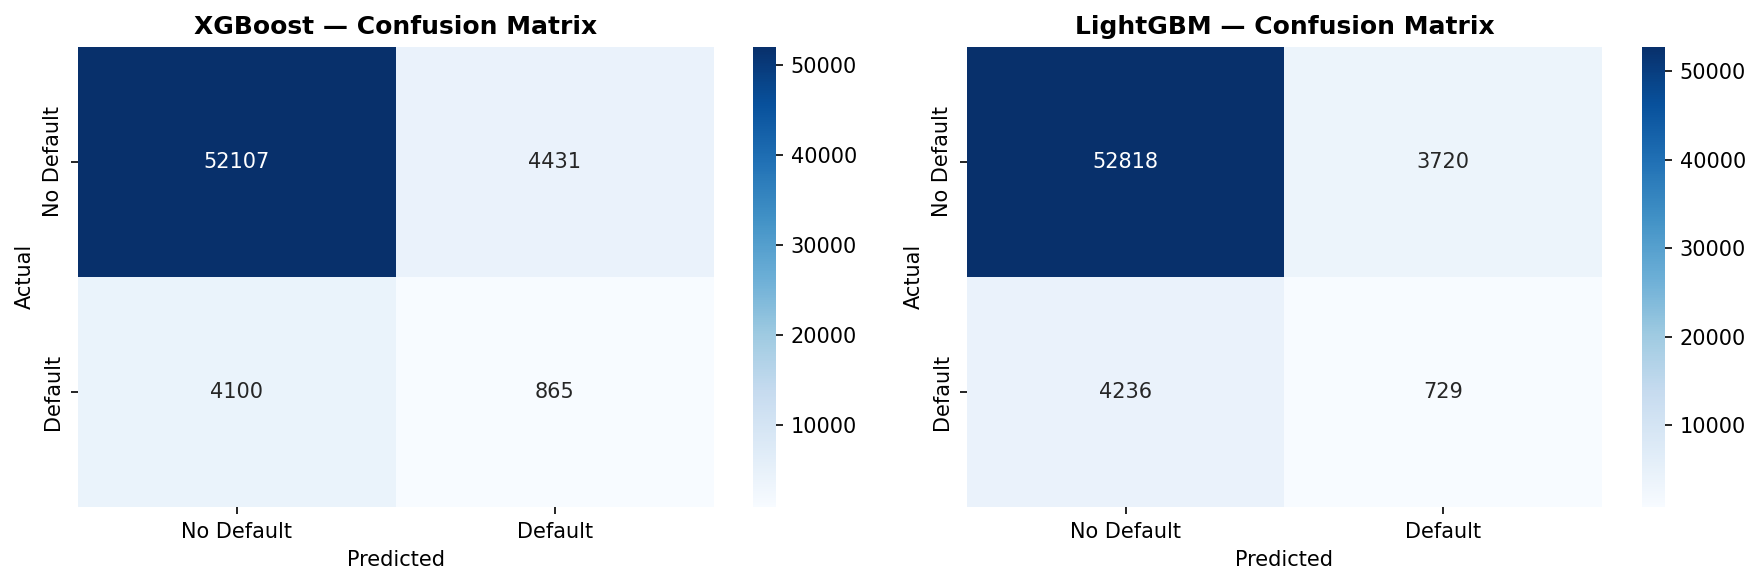

In [21]:
# ── Cell 7: Confusion Matrices ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('chart_confusion_matrices.png', bbox_inches='tight')
plt.show()

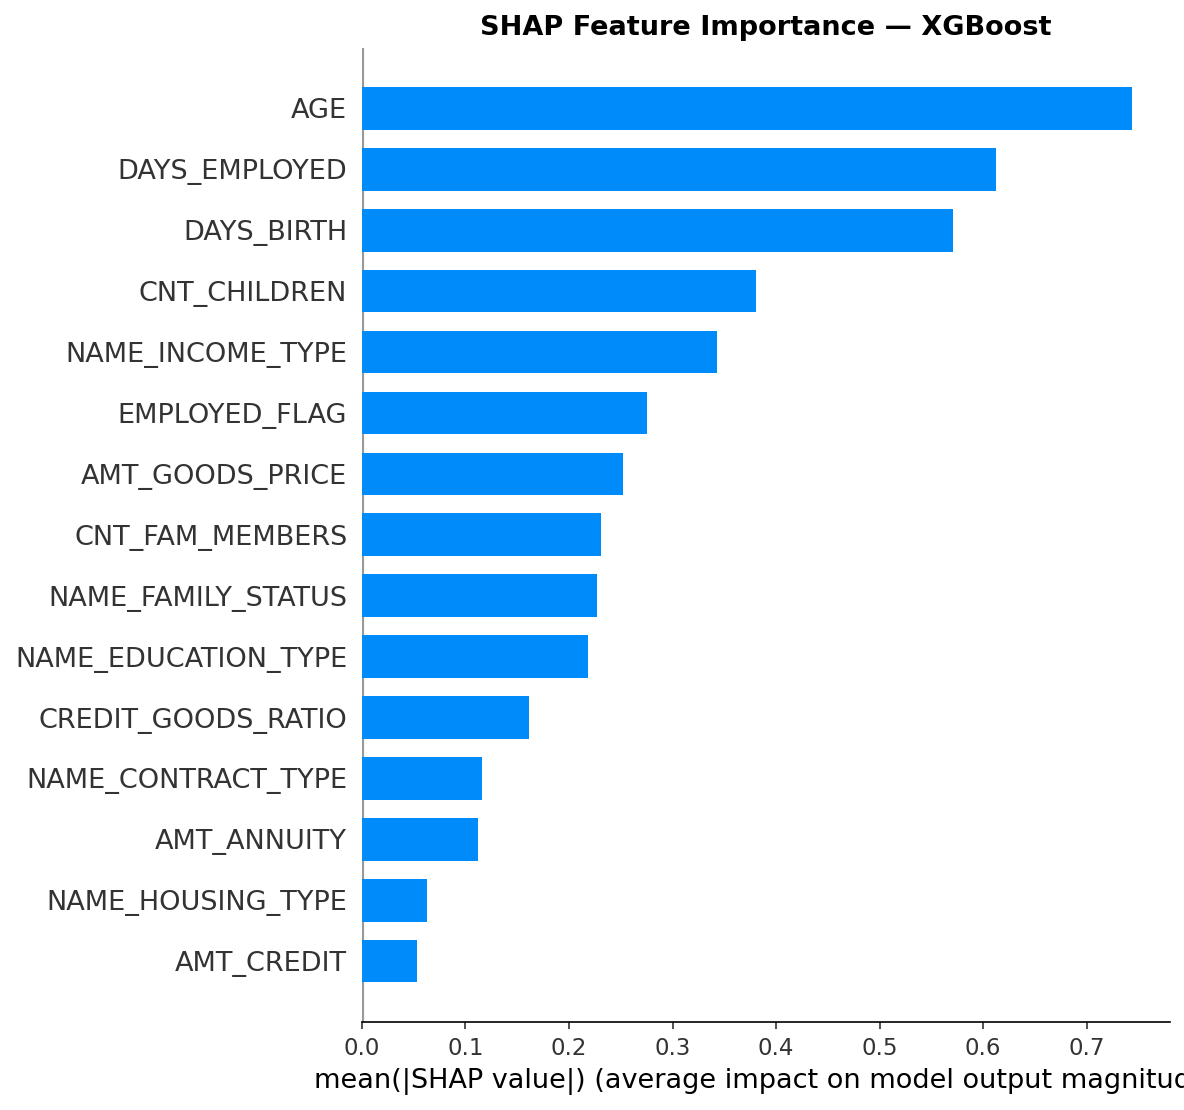

In [22]:
# ── Cell 8: SHAP Summary Plot (XGBoost) ──────────────────────────────
# Use a sample of 2000 rows for speed
X_sample = X_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, max_display=15,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_shap_bar.png', bbox_inches='tight')
plt.show()

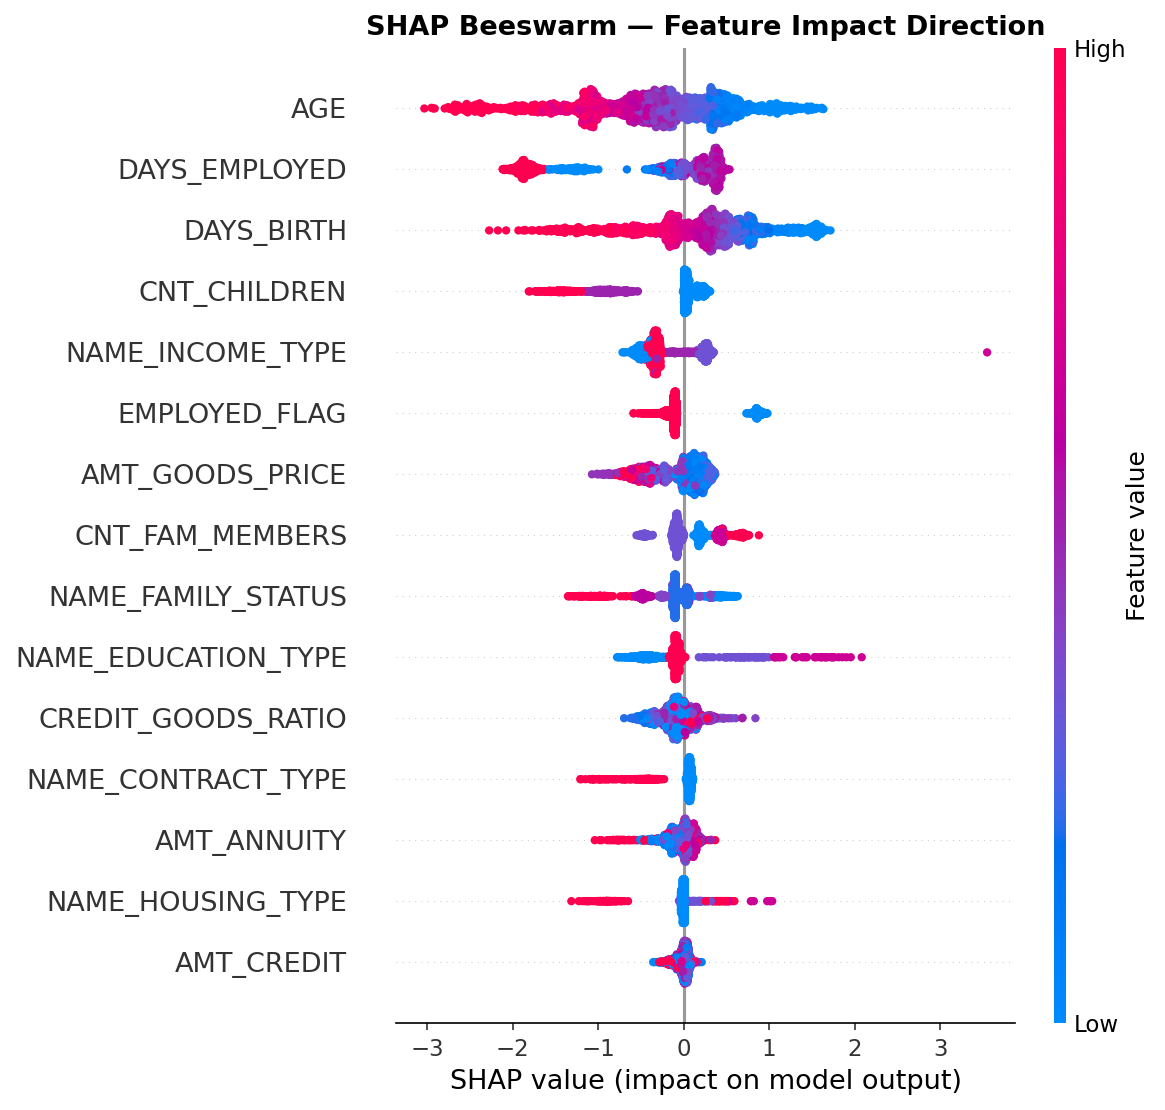


HOW TO READ THIS CHART:
  • Each dot = one prediction
  • Red dots  = high feature value
  • Blue dots = low feature value
  • Right of 0 → pushes toward DEFAULT
  • Left  of 0 → pushes toward NO DEFAULT



In [23]:
# ── Cell 9: SHAP Beeswarm (Direction of Impact) ───────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_shap_beeswarm.png', bbox_inches='tight')
plt.show()

print("""
HOW TO READ THIS CHART:
  • Each dot = one prediction
  • Red dots  = high feature value
  • Blue dots = low feature value
  • Right of 0 → pushes toward DEFAULT
  • Left  of 0 → pushes toward NO DEFAULT
""")

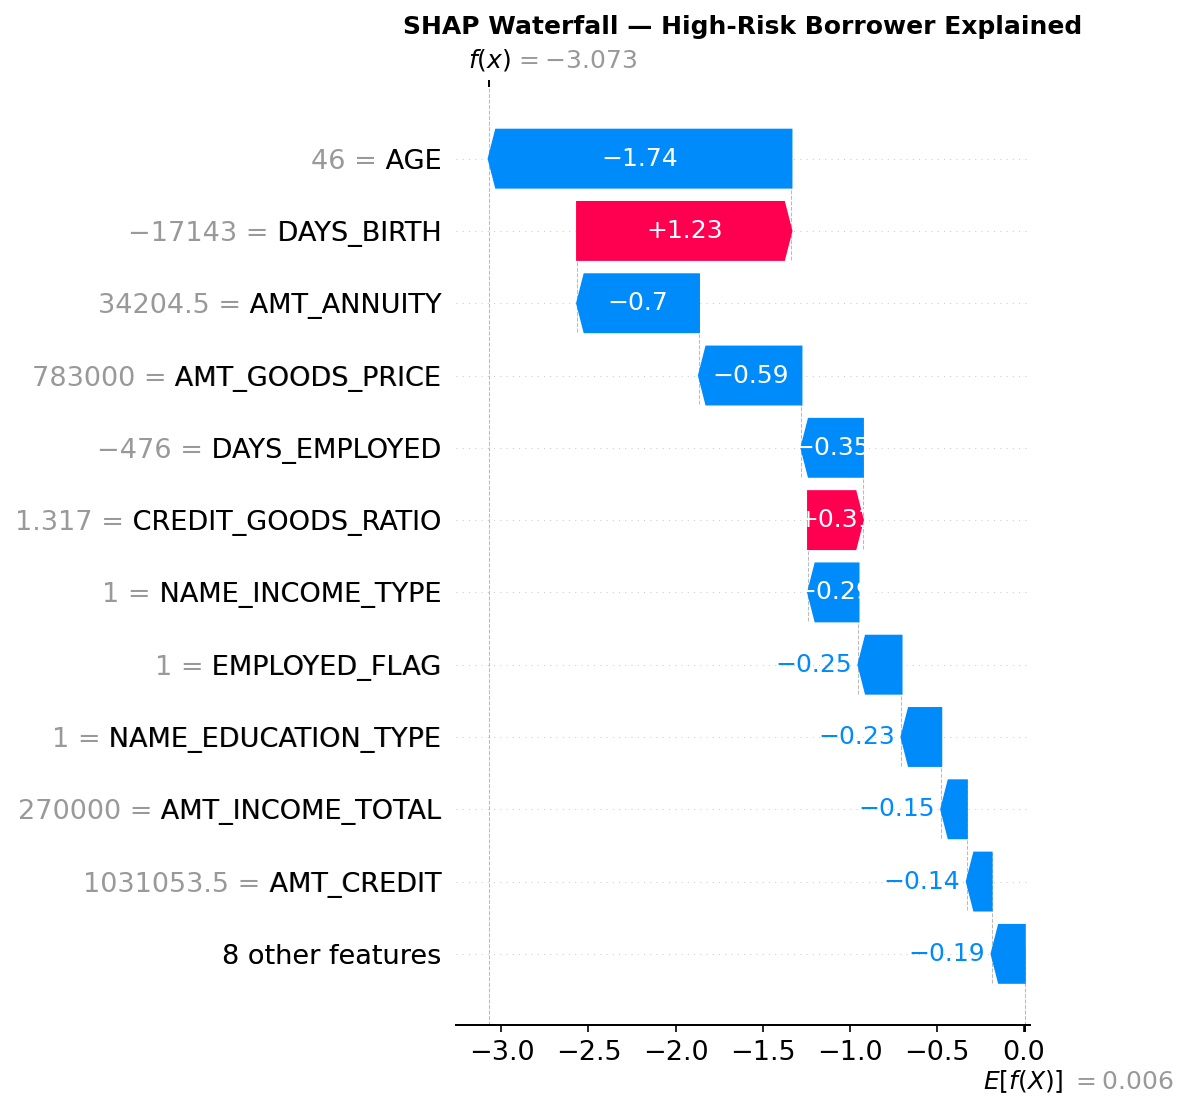

In [24]:
# ── Cell 10: SHAP Waterfall — Single Prediction ───────────────────────
# Find a high-risk defaulter in the test set
high_risk_idx = X_test[y_test == 1].index[0]
high_risk_pos = X_test.index.get_loc(high_risk_idx)

shap_explanation = shap.Explanation(
    values=shap_values[high_risk_pos],
    base_values=explainer.expected_value,
    data=X_sample.iloc[0],
    feature_names=X_test.columns.tolist()
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_explanation, max_display=12, show=False)
plt.title('SHAP Waterfall — High-Risk Borrower Explained', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_shap_waterfall.png', bbox_inches='tight')
plt.show()

In [25]:
# ── Cell 11: Save Models & Metrics ───────────────────────────────────
import joblib, os

SAVE_DIR = '/content/drive/MyDrive/credit_risk/models'
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(xgb,  f'{SAVE_DIR}/xgboost_model.pkl')
joblib.dump(lgbm, f'{SAVE_DIR}/lightgbm_model.pkl')
joblib.dump(X_test.columns.tolist(), f'{SAVE_DIR}/feature_names.pkl')

# Save metrics summary
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_rows = []
for name, res in results.items():
    metrics_rows.append({
        'Model': name,
        'ROC_AUC': round(res['auc'], 4),
        'Precision': round(precision_score(y_test, res['y_pred']), 4),
        'Recall':    round(recall_score(y_test, res['y_pred']), 4),
        'F1_Score':  round(f1_score(y_test, res['y_pred']), 4),
    })

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(f'{SAVE_DIR}/model_metrics.csv', index=False)

print("=== PHASE 4 COMPLETE ===")
print(metrics_df.to_string(index=False))
print(f"\nModels saved to: {SAVE_DIR}")
print("Charts saved: roc_curve, confusion_matrices, shap_bar, shap_beeswarm, shap_waterfall")

=== PHASE 4 COMPLETE ===
   Model  ROC_AUC  Precision  Recall  F1_Score
 XGBoost   0.6322     0.1633  0.1742    0.1686
LightGBM   0.6308     0.1639  0.1468    0.1549

Models saved to: /content/drive/MyDrive/credit_risk/models
Charts saved: roc_curve, confusion_matrices, shap_bar, shap_beeswarm, shap_waterfall
